# 01 — Data Exploration
Inspect the raw CoNLL-U files, Morpho Challenge data, and UniMorph lexicon.
Analyse vocabulary distributions, sentence lengths, and UPOS/morphological feature frequencies.

Train sentences: 12544


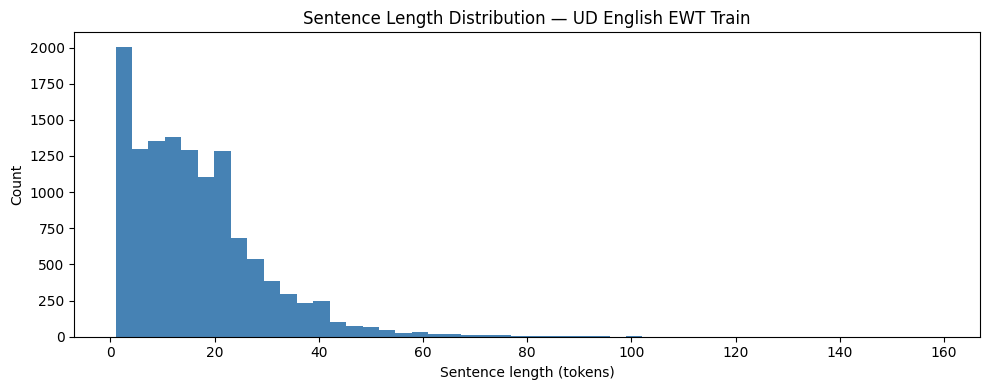

In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from src.data.conllu_parser import load_conllu_sentences, get_conllu_stats
from src.data.morpho_parser import parse_morpho_challenge_gold
from src.utils.config_loader import load_config

data_cfg = load_config('data_config', config_dir='../configs')
paths = data_cfg['paths']

train_sents = load_conllu_sentences('../' + paths['ud_english_train'])
print(f'Train sentences: {len(train_sents)}')

# Sentence length distribution
lengths = [len(s.forms) for s in train_sents]
plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='none')
plt.xlabel('Sentence length (tokens)')
plt.ylabel('Count')
plt.title('Sentence Length Distribution — UD English EWT Train')
plt.tight_layout()
plt.savefig('../outputs/figures/sentence_length_dist.png', dpi=150)
plt.show()

/tmp/ipykernel_362680/2457981726.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(tags), y=list(counts), palette='viridis')


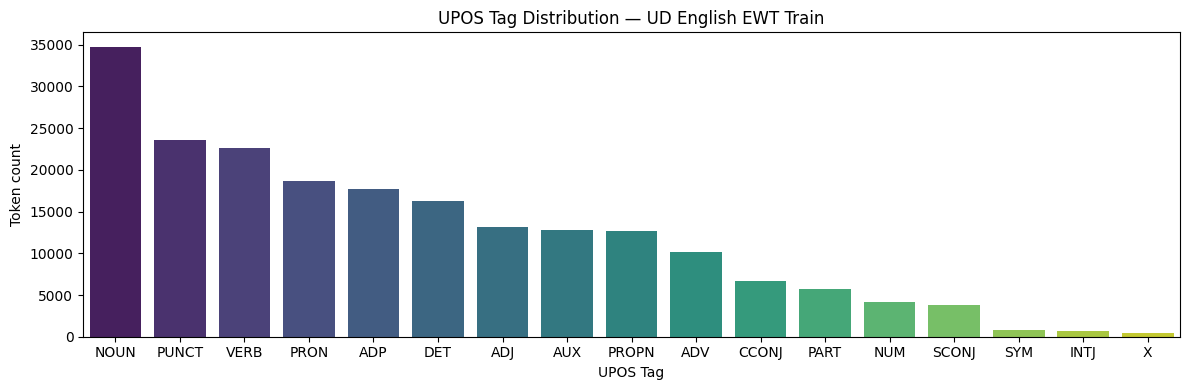

{'NOUN': 34751, 'PUNCT': 23596, 'VERB': 22576, 'PRON': 18677, 'ADP': 17714, 'DET': 16299, 'ADJ': 13136, 'AUX': 12815, 'PROPN': 12620, 'ADV': 10172, 'CCONJ': 6687, 'PART': 5748, 'NUM': 4126, 'SCONJ': 3819, 'SYM': 746, 'INTJ': 695, 'X': 400}


In [2]:
# UPOS distribution
upos_counter = Counter()
for sent in train_sents:
    upos_counter.update(sent.upos_tags)

tags, counts = zip(*sorted(upos_counter.items(), key=lambda x: -x[1]))
plt.figure(figsize=(12, 4))
sns.barplot(x=list(tags), y=list(counts), palette='viridis')
plt.xlabel('UPOS Tag')
plt.ylabel('Token count')
plt.title('UPOS Tag Distribution — UD English EWT Train')
plt.tight_layout()
plt.savefig('../outputs/figures/upos_distribution.png', dpi=150)
plt.show()
print(dict(upos_counter.most_common()))

/tmp/ipykernel_362680/3712422593.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(feat_names), y=list(feat_counts), palette='magma')


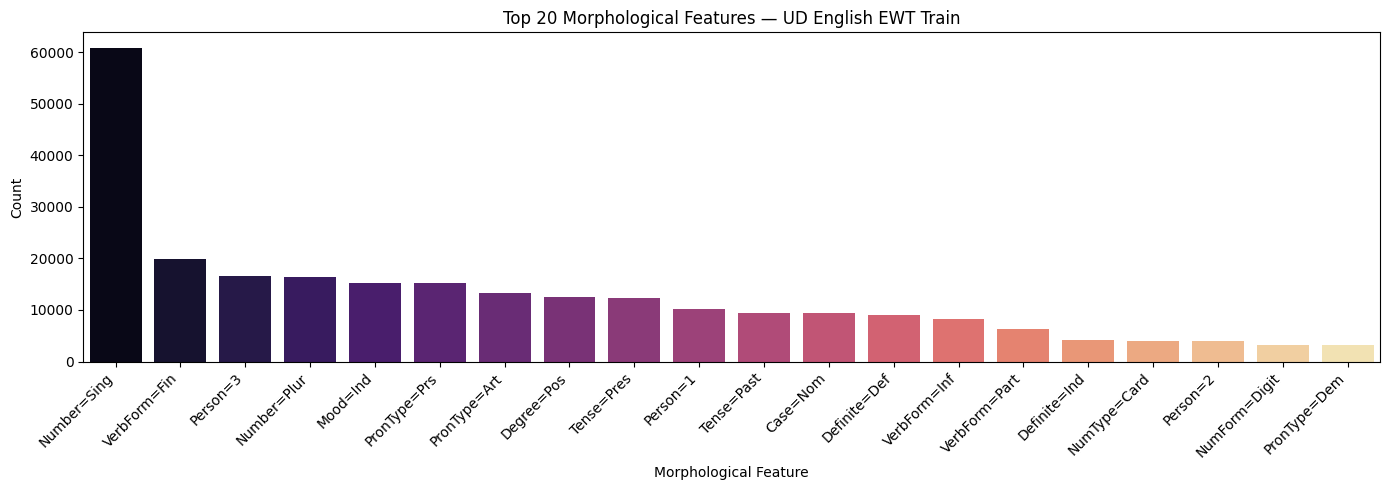

In [3]:
# Morphological feature distribution
feat_counter = Counter()
for sent in train_sents:
    for feat_dict in sent.morph_feats:
        for key, val in feat_dict.items():
            feat_counter[f'{key}={val}'] += 1

top_feats = feat_counter.most_common(20)
feat_names, feat_counts = zip(*top_feats)

plt.figure(figsize=(14, 5))
sns.barplot(x=list(feat_names), y=list(feat_counts), palette='magma')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Morphological Feature')
plt.ylabel('Count')
plt.title('Top 20 Morphological Features — UD English EWT Train')
plt.tight_layout()
plt.savefig('../outputs/figures/morph_features_dist.png', dpi=150)
plt.show()

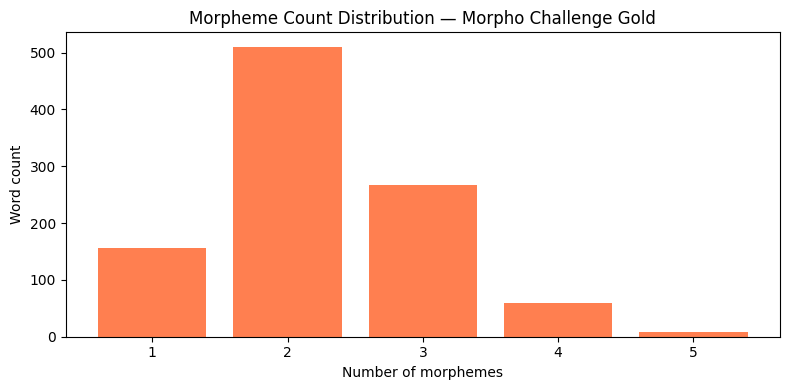

In [4]:
# Morpho Challenge gold standard analysis
morpho_gold = parse_morpho_challenge_gold('../' + paths['morpho_gold'])

morph_counts = Counter(entry.n_morphemes for entry in morpho_gold.values())
plt.figure(figsize=(8, 4))
plt.bar(morph_counts.keys(), morph_counts.values(), color='coral')
plt.xlabel('Number of morphemes')
plt.ylabel('Word count')
plt.title('Morpheme Count Distribution — Morpho Challenge Gold')
plt.tight_layout()
plt.savefig('../outputs/figures/morpheme_count_dist.png', dpi=150)
plt.show()